# 04 - Método da bisseção
Vamos aprender sobre como usar o método da bisseção para encontrar as raízes de funções reais.

Crie uma nova branch (versão) do repositório:

```bash
git branch semana4
```

Faça o checkout nessa nova branch:

```bash
git checkout semana4
```

A partir desta atividade, os arquivos de algoritmos ficarão dentro da pasta utils.

```txt
├─ utils/
│   └─ __init__.py
│   └─ algoritmos.py
```

<hr />

## Atividade 1
Escreva o método da bisseção dentro do arquivo $utils/algoritmos.py$.

In [ ]:
def bissecao(f,     
              a,    
              b,    
              TOL,   
              iter=16):  
    c = (a + b) / 2  b
    if f(a) * f(b) > 0:
        raise ValueError("Nenhuma raiz encontrada no intervalo.")
    else:
        i = 0  
        ERRO = abs(f(b) - f(a))  
        while ERRO > TOL and i < iter:  a
            c = (a + b) / 2.0
            if f(c) == 0:
                return c, i
            elif f(a) * f(c) < 0:
                b = c
            else:
                a = c
            i += 1
            ERRO = abs(f(b) - f(a))
        return c, i

Importe e teste a função:  

$$
f(x) = x^3 - x - 2
$$

Em que os valores iniciais a e b são obtidos graficamente.

In [10]:
%pip install numpy matplotlib


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


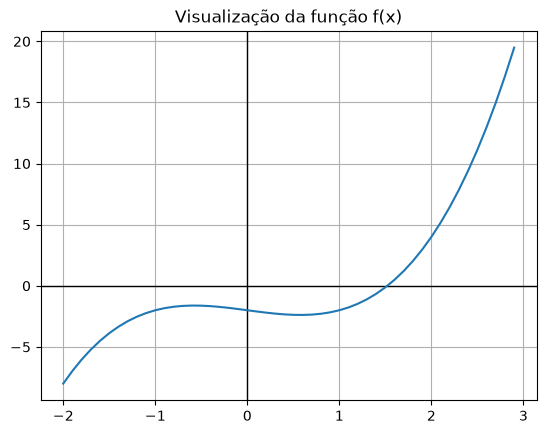

raiz = 1.5213775634765625 , i = 16


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os


sys.path.append(os.path.abspath(os.path.join('..')))

from utils.algoritmos import bissecao


def f(x):
    return x**3 - x - 2

def plot(f, number=1):
    
    x_vals = np.arange(-2, 3, 0.1)
    y_vals = f(x_vals)

    plt.axhline(0, color="black", linewidth=1)  # eixo x
    plt.axvline(0, color="black", linewidth=1)  # eixo y
    plt.plot(x_vals, y_vals)
    plt.grid(True)
    plt.title("Visualização da função f(x)")
    plt.show()
    plt.close()

def main():
    plot(f, 1)
    r, i = bissecao(f, 1, 2, 1e-15)
    print(f"raiz = {r} , i = {i}")

if __name__ == "__main__":
    main()

## Atividade 2
Considere a equação  

$$
\sqrt{x} = \cos(x).
$$  

Use o método da bisseção com intervalo inicial obtido por gráfico (entre 0 e 1) para calcular um valor aproximado com precisão de $10^{-4}$ para no máximo 4 iterações.

**Resposta:**  
$
x \approx 0.6875
$ 

In [12]:
import math


def g(x):
    return math.sqrt(x) - math.cos(x)

raiz, iteracoes = bissecao(g, 0.0, 1.0, 1e-4, iter=4)
print(f"raiz ≈ {raiz:.4f}, f(raiz)={g(raiz):.3e}, iterações={iteracoes}")

raiz ≈ 0.6875, f(raiz)=5.632e-02, iterações=4


## Atividade 3
Trace o gráfico e isole as três primeiras raízes positivas da função:  

$$
f(x) = 5\sin(x^2) - \exp\!\left(\frac{x}{10}\right)
$$  

em intervalos de comprimento $(0.1)$. Então, use o método da bisseção para obter aproximações dos zeros com precisão de $10^{-5}$.  

**Resposta:**  

- Intervalo $(0.4, 0.5)$, zero em $(x \approx 0.45931)$.  
- Intervalo $(1.7, 1.8)$, zero em $(x \approx 1.7036)$.  
- Intervalo $(2.5, 2.6)$, zero em $(x \approx 2.5582)$. 

intervalo=(0.4, 0.5), raiz=0.45931, iterações=14
intervalo=(1.7, 1.8), raiz=1.70357, iterações=14
intervalo=(2.5, 2.6), raiz=2.55821, iterações=14


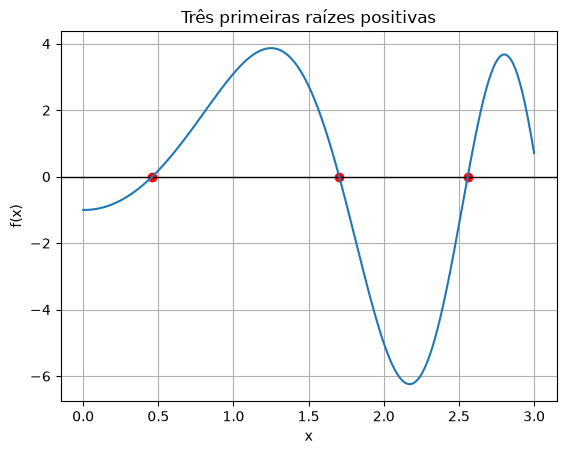

In [13]:
def f3(x):
    return 5 * np.sin(x**2) - np.exp(x / 10)

intervalos = [(0.4, 0.5), (1.7, 1.8), (2.5, 2.6)]
raizes = []
for a, b in intervalos:
    raiz, iteracoes = bissecao(f3, a, b, 1e-5, iter=30)
    raizes.append(raiz)
    print(f"intervalo=({a}, {b}), raiz={raiz:.5f}, iterações={iteracoes}")

x_vals = np.linspace(0.0, 3.0, 600)
plt.axhline(0, color="black", linewidth=1)
plt.plot(x_vals, f3(x_vals))
plt.scatter(raizes, [0] * len(raizes), color="red")
plt.grid(True)
plt.title("Três primeiras raízes positivas")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()
plt.close()

## Atividade 4
O desenho abaixo mostra um circuito não linear envolvendo uma fonte de tensão constante, um diodo retificador e um resistor.  

Sabendo que a relação entre a corrente ($I_d$) e a tensão ($v_d$) no diodo é dada pela seguinte expressão:

$ I_d = I_R \left( \exp\left(\tfrac{v_d}{v_t}\right) - 1 \right) $

onde $I_R$ é a corrente de condução reversa e $v_t$ a tensão térmica, dada por  

$ v_t = \tfrac{kT}{q} $

com $k$ a constante de Boltzmann, $T$ a temperatura de operação e $q$ a carga do elétron.  

Aqui, $I_R = 1\,pA = 10^{-12}\,A$, $T = 300\,K$.  

Escreva o problema como uma equação na incógnita $v_d$, usando o método da bisseção, e resolva-o com **3 algarismos significativos** para os seguintes casos:

- $V = 30 \, V$ e $R = 1 \, k\Omega$  
- $V = 3 \, V$ e $R = 1 \, k\Omega$  
- $V = 3 \, V$ e $R = 10 \, k\Omega$  
- $V = 300 \, mV$ e $R = 1 \, k\Omega$  
- $V = -300 \, mV$ e $R = 1 \, k\Omega$  
- $V = -30 \, V$ e $R = 1 \, k\Omega$  
- $V = -30 \, V$ e $R = 10 \, k\Omega$  

![Circuito](https://www.ufrgs.br/reamat/CalculoNumerico/livro-py/main4x.png)

**Dica:**  
A equação do circuito é:

$ V = R I_d + v_d $

**Resposta:**  
a) $0.623$  
b) $0.559$  
c) $0.500$  
d) $0.300$  
e) $-0.300$  
f) $-30$  
g) $-30$

In [14]:
k_boltzmann = 1.380649e-23
charge = 1.602176634e-19
reverse_current = 1e-12
temperature = 300.0
thermal_voltage = k_boltzmann * temperature / charge


def diode_voltage(V, R):
    def equation(vd):
        try:
            diode_current = reverse_current * math.expm1(vd / thermal_voltage)
        except OverflowError:
            diode_current = math.inf
        return R * diode_current + vd - V

    return bissecao(equation, min(V, 0.0), max(V, 0.0), 1e-12, iter=200)[0]

casos = [(30.0, 1e3), (3.0, 1e3), (3.0, 10e3),
         (0.3, 1e3), (-0.3, 1e3), (-30.0, 1e3), (-30.0, 10e3)]
for V, R in casos:
    vd = diode_voltage(V, R)
    print(f"V={V:g} V, R={R / 1e3:g} kOhm -> vd={vd:.3g} V")

V=30 V, R=1 kOhm -> vd=0.623 V
V=3 V, R=1 kOhm -> vd=0.559 V
V=3 V, R=10 kOhm -> vd=0.5 V
V=0.3 V, R=1 kOhm -> vd=0.3 V
V=-0.3 V, R=1 kOhm -> vd=-0.3 V
V=-30 V, R=1 kOhm -> vd=-30 V
V=-30 V, R=10 kOhm -> vd=-30 V


## Atividade 5
Calcule o comprimento do cabo ($C$) entre duas torres de transmissão (i.e., a catenária).  

A distância entre as torres é de $d = 500 \, m$.  

A flecha máxima permitida é $f_{max} = 50 \, m$.  

Flecha é a distância vertical entre uma reta que liga os dois pontos de fixação.  

A flecha ($f$) depende do comprimento do vão ($d$) e da tração ($C$) aplicada ao cabo.  

O seu modelo matemático pode ser:

$ f = C \left[ \cosh\left(\tfrac{d}{2C}\right) - 1 \right] \quad $

**Resposta:** $633.1621 \, m$

In [15]:
distancia = 500.0
flecha_maxima = 50.0


def flecha(c):
    return c * (math.cosh(distancia / (2 * c)) - 1) - flecha_maxima

cabo, iteracoes = bissecao(flecha, 100.0, 10_000.0, 1e-8, iter=100)
print(f"C ≈ {cabo:.4f} m, flecha={flecha(cabo) + flecha_maxima:.4f} m, iterações={iteracoes}")

C ≈ 633.1622 m, flecha=50.0000 m, iterações=40


## Atividade 6
Um retificador de meia onda a diodo alimenta uma carga indutiva-resistiva ($f = 1 \, kHz$, $L = 100 \, mH$ e $R = 1 \, k\Omega$).  

Encontre o ângulo $\beta$ para o qual a corrente $I_d$ no diodo se anula.  

Considere o seguinte modelo matemático:

$ I_d = \sin(\beta - \phi) + \sin(\phi)e^{-\tfrac{\beta}{\tan(\phi)}} \quad $

com  

$ \tan(\phi) = \tfrac{2\pi f L}{R} $

**Resposta:** $\beta = 212.2284^\circ$

In [16]:
frequencia = 1e3
indutancia = 100e-3
resistencia = 1e3

tan_phi = 2 * math.pi * frequencia * indutancia / resistencia
phi = math.atan(tan_phi)


def corrente(beta):
    return math.sin(beta - phi) + math.sin(phi) * math.exp(-beta / tan_phi)

beta, iteracoes = bissecao(corrente, math.pi, 2 * math.pi, 1e-10, iter=100)
print(f"phi={math.degrees(phi):.4f} graus")
print(f"beta={math.degrees(beta):.4f} graus, corrente={corrente(beta):.3e}, iterações={iteracoes}")

phi=32.1419 graus
beta=212.2258 graus, corrente=-2.586e-11, iterações=35


## Versionando o código

Submeta a branch para o servidor:

```bash
git add .
git commit -m "Semana 4"
git push origin semana4
```